In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

from thermal_ofc import ThermalOFC

# Create the model

In [2]:
# Create model
model = ThermalOFC(Nx=100, d=4e-3, delta_th=0.1, v=1., theta=2.75e-4, omega_0=1e13)
model.summary()

Thermal OFC model summary:
  Grid size: 100 x 100

  Dissipation (d): 4.0e-03
  Threshold disorder (delta_th): 1.0e-01
  Loading velocity (v): 1.0e+00 length/time
  Derived stiffness (K): 1.61e-02 stress/length
  Derived loading rate: 1.61e-02 stress/time

  Attempt frequency (omega_0): 1.0e+13 1/time
  Thermal activation scale (theta): 2.8e-04 stress

  Time scale ratio (omega_0 * theta / loading_rate): 1.71e+11 (dimensionless)


# Run model to reach a steady state

In [3]:
# Run the model for a certain number of events
N_ev = 20_000  # number of events to simulate

time = np.zeros(N_ev+1) # time array
mean_stress = np.zeros(N_ev+1)  # mean stress array
mean_stress[0] = np.mean(model.stress)  # initial mean stress

for iev in range(N_ev):
    print(f"Event {iev+1}/{N_ev}", end="\r")
    _, _ = model.step()
    mean_stress[iev+1] = np.mean(model.stress)
    time[iev+1] = model.time
print("\nSimulation completed.\n")

# Extract earthquake data
model.catalog.summary()  # Summary of the earthquake catalog
eq = model.catalog.df  # extract earthquake catalog

Event 20000/20000
Simulation completed.


Catalog stats:
  Time span: 0.00 - 37.53
  Number of events: 20000
  Min-Max event size: 1 - 4238
  Min-Max magnitude: -0.13 - 2.47
  Proportion of event types: 
rupture_type
thermal    1.0
Name: proportion, dtype: float64


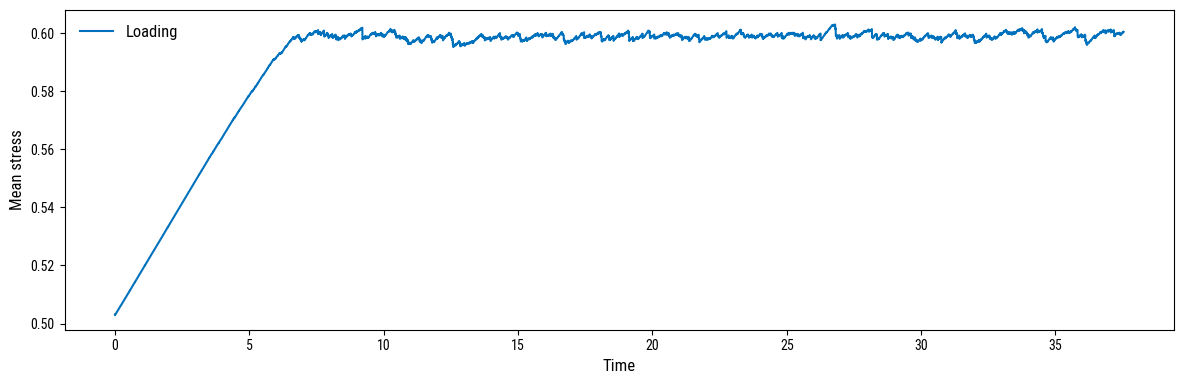

In [4]:
# Show loading history
fig, ax = plt.subplots(figsize=(12, 4))
ax.set_xlabel("Time")
ax.set_ylabel("Mean stress")

ax.plot(time, mean_stress, label="Loading")

ax.legend()

plt.tight_layout()
plt.show()

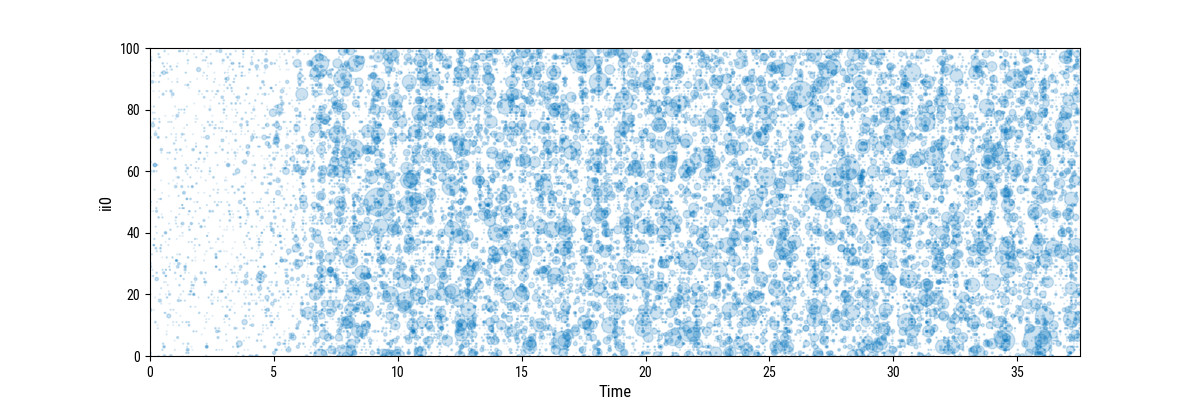

In [13]:
# Show catalog
fig, ax = plt.subplots(figsize=(12, 4))
ax.set_xlabel("Time")
ax.set_ylabel("ii0")
ax.set_xlim(0, time[-1])
ax.set_ylim(0, model.Nx)

ax.scatter(eq["time"], eq["ii0"], s=eq["size"]/10, alpha=0.2, label="Earthquakes")

# Let the system creep (relax) without loading

In [6]:
# Let the system creep
N_ev = 30_000  # number of events to simulate
creep_log_time = np.zeros(N_ev)  # time array for creep
creep_mean_stress = np.zeros(N_ev)  # mean stress array for creep
creep_mean_stress[0] = np.mean(model.stress)  # initial mean

iev = 0
while (iev < N_ev):
    print(f"Creep event {iev+1}/{N_ev}", end="\r")
    event, log_time = model.creep_logtime()
    creep_mean_stress[iev] = np.mean(model.stress)
    creep_log_time[iev] = model.log_time
    
    iev += 1
    
creep_time = creep_log_time[:iev]  # trim time array to actual number of events
creep_mean_stress = creep_mean_stress[:iev]  # trim mean stress array to actual number of events

print("\nCreep simulation completed.\n")
model.catalog.summary()  # Summary of the earthquake catalog after creep
eq = model.catalog.df  # extract earthquake catalog after creep

Creep event 30000/30000
Creep simulation completed.


Catalog stats:
  Time span: 0.00 - inf
  Number of events: 50000
  Min-Max event size: 1 - 4238
  Min-Max magnitude: -0.23 - 2.47
  Proportion of event types: 
rupture_type
thermal    1.0
Name: proportion, dtype: float64


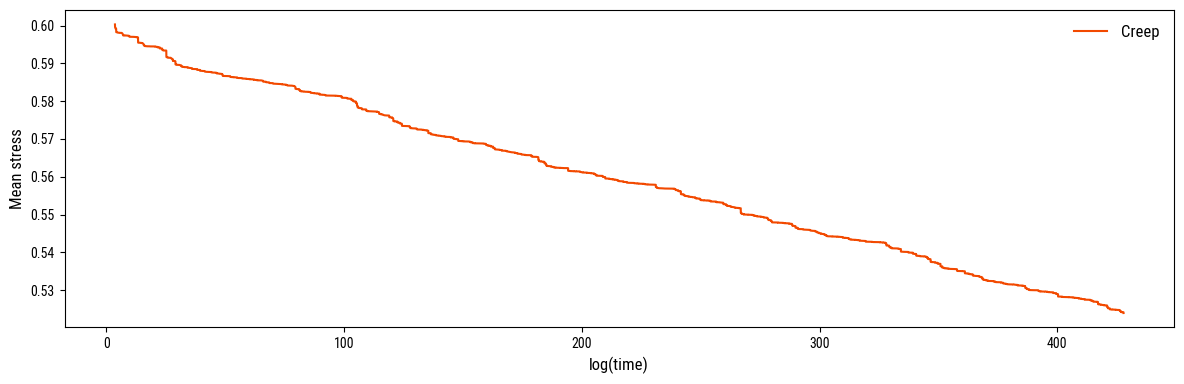

In [7]:
# Show creeping history
fig, ax = plt.subplots(figsize=(12, 4))
ax.set_xlabel("log(time)")
ax.set_ylabel("Mean stress")

ax.plot(creep_log_time, creep_mean_stress, label="Creep", c="C1")

ax.legend()

plt.tight_layout()
plt.show()

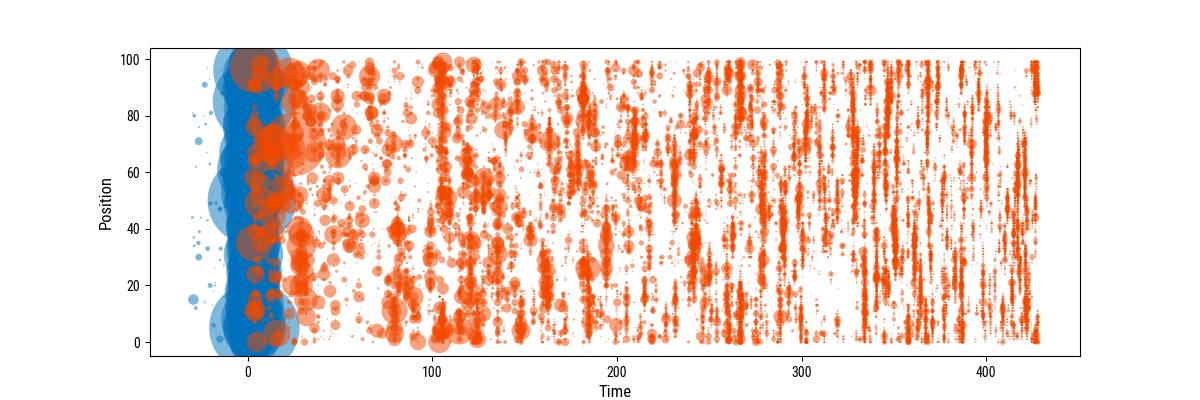

In [12]:
# Show earthquake catalog
fig, ax = plt.subplots(figsize=(12, 4))
ax.set_xlabel("Time")
ax.set_ylabel("Position")

# --> Loading earthquakes in blue
during_loading = np.isfinite(eq.time)
ax.scatter(eq.log_time[during_loading], eq.ii0[during_loading], s=eq["size"][during_loading], alpha=0.5, edgecolors="none", label="Loading EQs", c="C0")

# --> Creep earthquakes in orange
ax.scatter(eq.log_time[~during_loading], eq.ii0[~during_loading], s=eq["size"][~during_loading], alpha=0.5, edgecolors="none", label="Creep EQs", c="C1")

plt.show()

In [ ]:
# Fit a power-law decay to the creep stress
fit_time = creep_time[:-1] - time[-1]
fit_stress = creep_mean_stress[:-1]

def powerlaw_decay(t, A, B, C, D):
    return A / (t + B)**C + D
popt, pcov = curve_fit(powerlaw_decay, fit_time, fit_stress, maxfev=10000, p0=[0.5, 0.5, 0.5, 0.5])
A_fit, B_fit, C_fit, D_fit = popt
print(f"Fitted parameters: A={A_fit:.3f}, B={B_fit:.3f}, C={C_fit:.3f}", f"D={D_fit:.3f}")

# Show creep data and fit
fig, ax = plt.subplots(figsize=(6, 4))
ax.set_xlabel("Time")
ax.set_ylabel("Mean stress")

ax.plot(fit_time, fit_stress, label="Creep data")
ax.plot(fit_time, powerlaw_decay(fit_time, *popt), label="Power-law fit", linestyle="--")

plt.tight_layout()
plt.show()

Estimated power-law exponent: -1.28


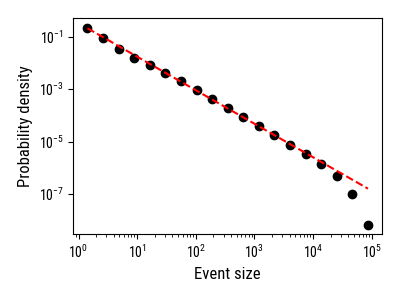

In [16]:
# Scaling of event sizes
# --> Select events
tmin = 85  # minimum time to consider (to avoid the effects of the initial transient)
eq_in_window = eq[eq["time"] >= tmin]  # select earthquakes that occur after time tmin

# --> Compute histogram of event sizes
size_bins = np.logspace(np.log10(eq["size"].min()), np.log10(eq["size"].max()), num=20)  # logarithmic bins for event sizes
hist, bin_edges = np.histogram(eq_in_window["size"], bins=size_bins, density=True)  # histogram of event sizes (normalized to get a probability density)
size_bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# --> Fit a power law to the distribution of event sizes
in_range = (size_bin_centers > 10) & (size_bin_centers < 10_000)  # select the range of event sizes to fit (e.g., between 10 and 1000)
p = np.polyfit(np.log(size_bin_centers[in_range]), np.log(hist[in_range]), deg=1)  # fit a power law (linear fit in log-log space)
print(f"Estimated power-law exponent: {p[0]:.2f}")

# Plot
fig, ax = plt.subplots(figsize=(4, 3))
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Event size")
ax.set_ylabel("Probability density")

ax.plot(size_bin_centers, hist, marker="o", linestyle="", c="k")
ax.plot(size_bin_centers, np.exp(p[0] * np.log(size_bin_centers) + p[1]), linestyle="--", c="r")

plt.tight_layout()
plt.show()

Number of mainshocks with magnitude between 2.3 and 2.7: 5


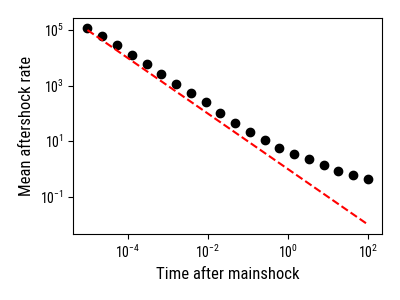

In [ ]:
# Aftershocks
# --> Select mainshocks in a certain magnitude range
main_mag = 2.5  # magnitude of the mainshock to analyze
dm = 0.2  # magnitude window to select aftershocks (e.g., between main_mag-dm and main_mag+dm)
in_mag_range = (eq["mag"] >= main_mag - dm) & (eq["mag"] <= main_mag + dm) & (eq["time"] > 2000)  # select earthquakes in the magnitude range

mainshocks = eq[in_mag_range]  # mainshocks to analyze
print(f"Number of mainshocks with magnitude between {main_mag-dm} and {main_mag+dm}: {len(mainshocks)}")

# --> Define time windows after each mainshock to look for aftershocks
dt = 1  # characteristic time unit (e.g., 1 day)
time_windows = dt * np.logspace(-5, 2, num=30)  # logarithmic time windows after the mainshock (e.g., from 1e-5 to 1 time unit)

# --> Count aftershocks in each time window
aftershock_counts = np.zeros((len(mainshocks), len(time_windows)))  # array to store the number of aftershocks for each mainshock and time window

for ii in range(len(mainshocks)):
    main_time = mainshocks.iloc[ii]["time"]  # time of the mainshock
    for jj, dt_window in enumerate(time_windows):
        aftershocks = eq[(eq["time"] > main_time) & (eq["time"] <= main_time + dt_window)]  # select aftershocks in the time window after the mainshock
        aftershock_counts[ii, jj] = len(aftershocks)  # count the number of aftershocks

# --> Decay of aftershock rate with time
mean_aftershock_rate = np.mean(aftershock_counts, axis=0) / time_windows
fig, ax = plt.subplots(figsize=(4, 3))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Time after mainshock")
ax.set_ylabel("Mean aftershock rate")

ax.plot(time_windows, mean_aftershock_rate, marker="o", linestyle="", c="k")
ax.plot(time_windows, 1/time_windows, linestyle="--", c="r")  # plot a reference line with Omori's law decay (1/time)

plt.tight_layout()
plt.show()